# Customer Churn Data

In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
preprocessed_data = pd.read_csv("../data/processed/preprocessed_WA_Fn-UseC_-Telco-Customer-Churn.csv")

# handling numerical features

In [3]:
# fill missing values with the median for numeric columns
numeric_cols = preprocessed_data.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    preprocessed_data[col].fillna(preprocessed_data[col].median(), inplace=True)

# normalize/standardize numeric variables: For XGBoost, normalization is not strictly necessary, but it can help with convergence and performance. Here, we will standardize the numeric columns to have a mean of 0 and a standard deviation of 1.
# preprocessed_data[numeric_cols] = (preprocessed_data[numeric_cols] - preprocessed_data[numeric_cols].mean()) / preprocessed_data[numeric_cols].std()


/var/folders/96/vqrfcvzj57l2h02bbvc1nkrc0000gn/T/ipykernel_85423/2509797463.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  preprocessed_data[col].fillna(preprocessed_data[col].median(), inplace=True)
/var/folders/96/vqrfcvzj57l2h02bbvc1nkrc0000gn/T/ipykernel_85423/2509797463.py:5: ChainedAssignmentError: A value is being set on 

# Handling categorical variables

In [5]:

# identify categorical columns with missing values and fill them with the mode
categorical_cols = preprocessed_data.select_dtypes(include=['object', 'str']).columns
for col in categorical_cols:
    if preprocessed_data[col].isnull().any():
        preprocessed_data[col].fillna(preprocessed_data[col].mode()[0], inplace=True)



In [6]:
preprocessed_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

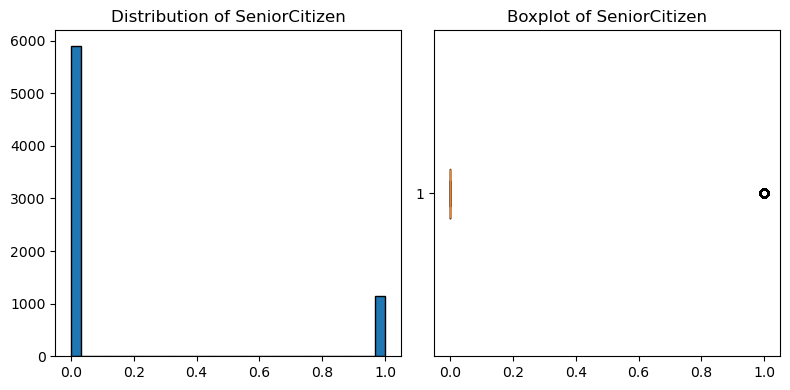

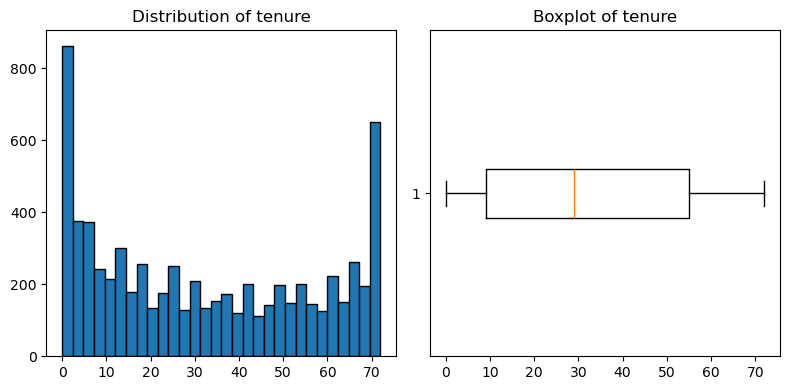

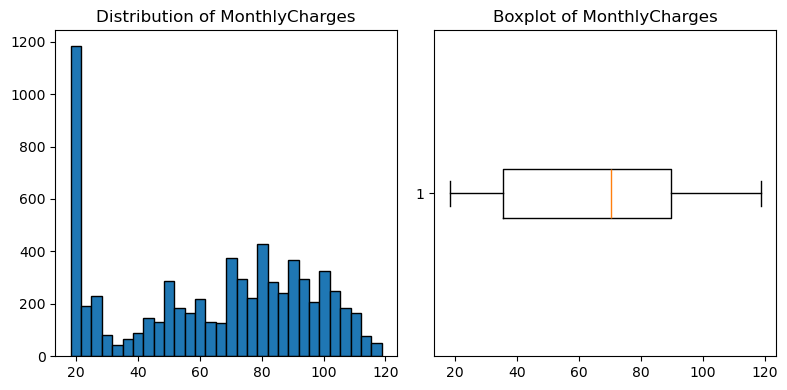

In [7]:
# check distribution of the numerical features to correct for skewness and outliers if necessary
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.hist(preprocessed_data[col], bins=30, edgecolor='k')
    plt.title(f"Distribution of {col}")
    plt.subplot(1, 2, 2)
    plt.boxplot(preprocessed_data[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

In [8]:
# check distribution of target variable and balance if necessary (e.g., using SMOTE or undersampling)
target_col = 'Churn'  # replace with the actual name of your target column
print(f"Distribution of {target_col}:")
print(preprocessed_data[target_col].value_counts())

Distribution of Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
